In [2]:
import tensorflow as tf

In [3]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [4]:
import tensorflow as tf

x = tf.constant([1, 2, 3, 4, 5])

print(x)

tf.Tensor([1 2 3 4 5], shape=(5,), dtype=int32)


Image Size: (740, 493, 3)
Image Size: (1561, 1920, 3)
Image Size: (1285, 1920, 3)
Image Size: (740, 740, 3)
Image Size: (740, 740, 3)
Image Size: (825, 1100, 3)


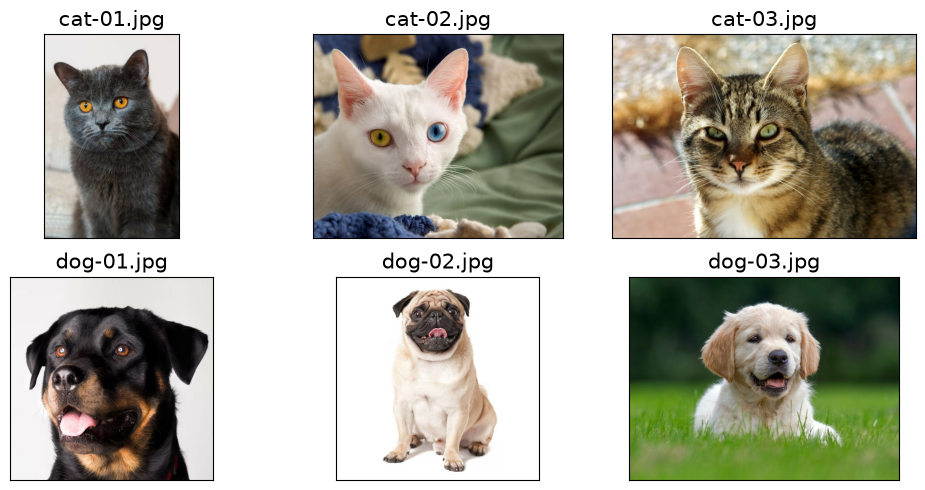

In [3]:
import matplotlib.pyplot as plt
import os
import tensorflow as tf

fig = plt.figure(figsize=(10, 5))

image_dir = r'C:\Users\SIC\Desktop\Projects\SIC-TensorFlow\cat_dog_images'  # Change this to your image directory
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

file_list = sorted(
    os.path.join(image_dir, filename)
    for filename in os.listdir(image_dir)
    if filename.lower().endswith(image_extensions)
)

for i, file in enumerate(file_list[:6]):
    img_raw = tf.io.read_file(file)
    img = tf.image.decode_image(img_raw, channels=3)

    print("Image Size:", img.shape)

    ax = fig.add_subplot(2, 3, i + 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(img)
    ax.set_title(os.path.basename(file), size=15)

plt.tight_layout()
plt.show()


In [4]:
def preprocess(path, label):
    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, [80, 120])

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [ ]:
labels = [
    0 if "cat" in os.path.basename(path).lower() else 1
    for path in file_list
]

ds = tf.data.Dataset.from_tensor_slices((file_list, labels))
ds = ds.map(preprocess)

for X, y in ds:
    print(X.numpy(), y.numpy())

for X,y in ds:
    print(X.numpy(),y.numpy())

NameError: name 'ds' is not defined